Листок 3

Карцев Вcеволод, ЭФБО-02-24

In [1]:
%%capture
%pip install -q --disable-pip-version-check numpy scipy matplotlib imageio-ffmpeg

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio_ffmpeg
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy.integrate import solve_ivp, quad
from scipy.special import ellipk, ellipj
from pathlib import Path

Path('рисунки_3').mkdir(exist_ok=True)
Path('анимации_3').mkdir(exist_ok=True)
g = 9.81
plt.rcParams['animation.embed_limit'] = 80
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

def save_plot(name):
    plt.tight_layout()
    plt.savefig('рисунки_3/'+name+'.png', dpi=140, bbox_inches='tight')
    plt.show()

def show_animation(fig, update, name, frames=120):
    animation = FuncAnimation(fig, update, frames=frames, interval=40, blit=False, repeat=False)
    html = animation.to_html5_video().replace('autoplay', '')
    Path('анимации_3/'+name+'.html').write_text('<meta charset="utf-8">'+html, encoding='utf-8')
    plt.close(fig)
    display(HTML(html))

3.1. Равномерный спуск

Ось x направлена вправо, y — вверх. Трения нет. Скорость вниз постоянна: y' = -c, c > 0. Горизонтальную скорость обозначу u = x'.

На точку действуют сила тяжести (0, -m\*g) и реакция направляющей (Nx, Ny):

m\*x'' = Nx, m\*y'' = Ny - m\*g.

Так как y'' = 0, Ny = m\*g. Реакция перпендикулярна скорости (u,-c), поэтому Nx\*u - Ny\*c = 0. Исключаю реакцию:

u \* du/dt = g\*c.

При u(0) = u0 > 0 получаю u^2 = u0^2 + 2\*g\*c\*t.
После интегрирования:

x(t) = x0 + ((u0^2 + 2\*g\*c\*t)^(3/2) - u0^3)/(3\*g\*c),

y(t) = y0 - c\*t.

Из первого выражения исключаю t. Ответ:

y(x) = y0 + u0^2/(2\*g) - (u0^3 + 3\*g\*c\*(x-x0))^(2/3)/(2\*g).

Это ветвь полукубической параболы. Для движения вправо рассматриваю x >= x0. Начальная горизонтальная скорость положительна, чтобы реакция в начале была конечной.

Если записать кривую как y = f(x), то из -c = f'\*x' и x'' = -g\*f' получается уравнение f'' = g\*(f')^4/c^2. Найденная кривая ему удовлетворяет.

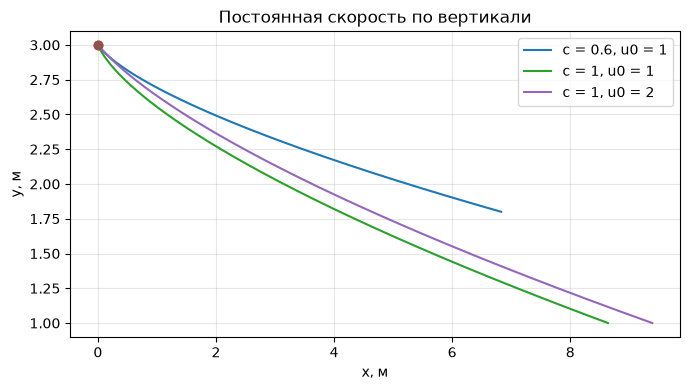

Изменение энергии на единицу массы: 1.0658141036401503e-14
Скорость по y: -1.0


In [3]:
def descent(t, c, u0, x0=0, y0=3):
    x = x0+((u0*u0+2*g*c*t)**1.5-u0**3)/(3*g*c)
    return x, y0-c*t

t = np.linspace(0, 2, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for c, u0 in [(0.6, 1), (1, 1), (1, 2)]:
    x, y = descent(t, c, u0)
    ax.plot(x, y, label=f'c = {c}, u0 = {u0}')
    ax.plot(x[0], y[0], 'o')
ax.set(xlabel='x, м', ylabel='y, м', title='Постоянная скорость по вертикали')
ax.legend()
ax.grid(alpha=0.3)
save_plot('3_1')

c, u0 = 1, 1
x, y = descent(t, c, u0)
u = np.sqrt(u0*u0+2*g*c*t)
energy = (u*u+c*c)/2+g*y
print('Изменение энергии на единицу массы:', np.ptp(energy))
print('Скорость по y:', (y[-1]-y[0])/(t[-1]-t[0]))

In [4]:
times = np.linspace(0, 2, 120)
x, y = descent(times, 1, 1)
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
ax.plot(x, y, color='gray')
point, = ax.plot([], [], 'o', color='tomato', ms=8)
text = ax.text(0.03, 0.93, '', transform=ax.transAxes, va='top')
ax.set(xlabel='x, м', ylabel='y, м')
ax.grid(alpha=0.3)
fig.tight_layout()
def update(k):
    point.set_data([x[k]], [y[k]])
    text.set_text(f't = {times[k]:.2f} с; vy = -1 м/с; vx = {np.sqrt(1+2*g*times[k]):.2f} м/с')
show_animation(fig, update, '3_1_спуск')

3.2. Бильярд в прямоугольнике

Область: 0 <= x <= a, 0 <= y <= b. Между ударами x'' = y'' = 0.
На вертикальной стенке vx меняет знак, vy сохраняется. На горизонтальной — наоборот. Скорость по модулю и энергия сохраняются. Попадания точно в угол отдельно не рассматриваю.

Метод развёртки: отражаю прямоугольник вместо скорости. В копиях прямоугольника траектория становится прямой:

X = x0 + vx\*t, Y = y0 + vy\*t.

Чтобы вернуться в исходный прямоугольник, складываю координаты:

x = a - abs((X mod 2a) - a), y = b - abs((Y mod 2b) - b).

Если отождествить противоположные стороны прямоугольника 2a на 2b, получается тор. Угловые координаты на нём: phi = pi\*X/a, psi = pi\*Y/b.

Траектория периодична, когда найдётся T > 0, для которого vx\*T = 2a\*m и vy\*T = 2b\*n с целыми m,n. Для ненулевых vx и vy это равносильно рациональности отношения a\*vy/(b\*vx).

При иррациональном отношении траектория не замыкается и плотно заполняет тор. При фиксированном таком направлении движение эргодично относительно равномерной меры на торе. Вся бильярдная система с произвольными направлениями не эргодична: величины |vx| и |vy| сохраняются.

Гамильтониан внутри области: H = (px^2 + py^2)/(2m). Отсюда x' = px/m, y' = py/m, px' = py' = 0. Удар меняет знак нормальной компоненты импульса.

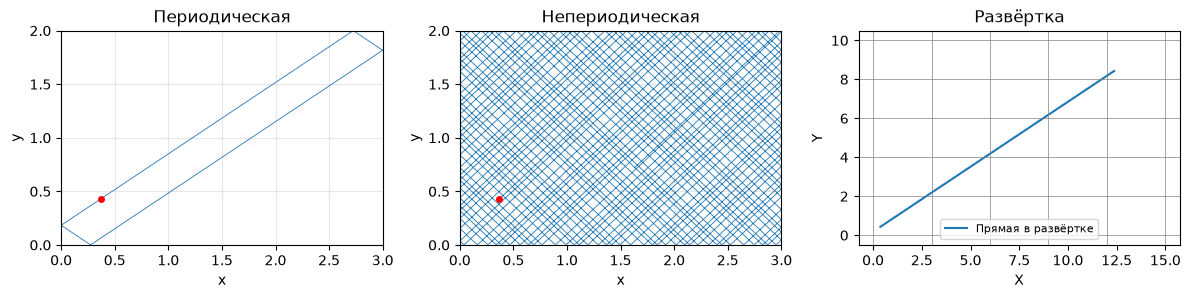

Период первой траектории: 6.0


In [5]:
a, bside = 3, 2
x0, y0 = 0.37, 0.43
vx = 1
speeds = [bside/a, np.sqrt(2)*bside/a]

def fold(x, length):
    return length-abs(x % (2*length)-length)

def torus(X, Y):
    phi, psi = np.pi*X/a, np.pi*Y/bside
    return ((2+0.6*np.cos(psi))*np.cos(phi),
            (2+0.6*np.cos(psi))*np.sin(phi), 0.6*np.sin(psi))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, vy, title, end in zip(axes[:2], speeds, ['Периодическая', 'Непериодическая'], [6, 160]):
    t = np.linspace(0, end, 10000)
    ax.plot(fold(x0+vx*t, a), fold(y0+vy*t, bside), lw=0.6)
    ax.plot(x0, y0, 'ro', ms=4)
    ax.set(xlim=(0,a), ylim=(0,bside), xlabel='x', ylabel='y', title=title)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
t = np.linspace(0, 12, 600)
axes[2].plot(x0+vx*t, y0+speeds[0]*t, label='Прямая в развёртке')
for xx in np.arange(0, 16, a): axes[2].axvline(xx, color='gray', lw=0.5)
for yy in np.arange(0, 12, bside): axes[2].axhline(yy, color='gray', lw=0.5)
axes[2].set(xlabel='X', ylabel='Y', title='Развёртка')
axes[2].set_aspect('equal')
axes[2].legend(fontsize=8)
save_plot('3_2')
print('Период первой траектории:', 2*a/vx)

In [6]:
fig = plt.figure(figsize=(9, 5), dpi=100)
times = np.linspace(0, 18, 120)
traces = []
for row, vy in enumerate(speeds):
    X, Y = x0+vx*times, y0+vy*times
    xx, yy = fold(X, a), fold(Y, bside)
    ax1 = fig.add_subplot(2, 3, row*3+1)
    ax1.set(xlim=(0,a), ylim=(0,bside), title='Бильярд', xlabel='x', ylabel='y')
    ax1.grid(alpha=0.3)
    ax1.set_aspect('equal')
    line1, = ax1.plot([], [], lw=0.8)
    dot1, = ax1.plot([], [], 'ro', ms=4)
    ax2 = fig.add_subplot(2, 3, row*3+2)
    ax2.set(xlim=(0,20), ylim=(0,20), title='Развёртка', xlabel='X', ylabel='Y')
    for q in np.arange(0,21,a): ax2.axvline(q, color='gray', lw=0.4)
    for q in np.arange(0,21,bside): ax2.axhline(q, color='gray', lw=0.4)
    line2, = ax2.plot([], [])
    dot2, = ax2.plot([], [], 'ro', ms=4)
    ax3 = fig.add_subplot(2, 3, row*3+3, projection='3d')
    u, v = np.meshgrid(np.linspace(0,2*np.pi,25), np.linspace(0,2*np.pi,12))
    ax3.plot_wireframe((2+0.6*np.cos(v))*np.cos(u), (2+0.6*np.cos(v))*np.sin(u),
                      0.6*np.sin(v), color='gray', alpha=0.25, linewidth=0.3)
    ax3.set(xlim=(-3,3), ylim=(-3,3), zlim=(-1,1), title='Тор')
    ax3.set_box_aspect((3,3,1))
    line3, = ax3.plot([], [], [])
    dot3, = ax3.plot([], [], [], 'ro', ms=4)
    traces.append((vy,line1,dot1,line2,dot2,line3,dot3))
fig.tight_layout(rect=[0,0,1,0.94])
label = fig.suptitle('')
def update(k):
    label.set_text(f't = {times[k]:.2f}; верх: a*vy/(b*vx) = 1; низ: sqrt(2)')
    # Мелкий шаг сохраняет изломы траектории между кадрами.
    tt = np.linspace(0, times[k], max(2, k*12))
    for vy,l1,d1,l2,d2,l3,d3 in traces:
        X, Y = x0+vx*tt, y0+vy*tt
        xx, yy = fold(X,a), fold(Y,bside)
        l1.set_data(xx,yy); d1.set_data([xx[-1]],[yy[-1]])
        l2.set_data(X,Y); d2.set_data([X[-1]],[Y[-1]])
        u,v,w = torus(X,Y)
        l3.set_data(u,v); l3.set_3d_properties(w)
        d3.set_data([u[-1]],[v[-1]]); d3.set_3d_properties([w[-1]])
show_animation(fig, update, '3_2_бильярд')

3.3. Цепная линия

Пусть rho — масса единицы длины цепи. Для участка от нижней точки до текущей горизонтальная составляющая натяжения H постоянна. Вертикальная составляющая равна весу участка: V = rho\*g\*s, где s — длина участка.

Натяжение направлено по касательной, поэтому y' = V/H. Также ds/dx = sqrt(1 + (y')^2).
Дифференцирую:

y'' = (rho\*g/H)\*sqrt(1 + (y')^2).

Ввожу a = H/(rho\*g) > 0 и p = y'. Тогда dp/sqrt(1+p^2) = dx/a.
После интегрирования asinh(p) = (x-xc)/a, то есть p = sinh((x-xc)/a).
Ещё раз интегрирую:

y = a\*cosh((x-xc)/a) + C.

При xc = 0, C = 0 получаю y = a\*cosh(x/a).
Для подвесов в (-L,0) и (L,0) удобно взять y = a\*(cosh(x/a)-cosh(L/a)).

Провисание: d = a\*(cosh(L/a)-1). Длина цепи: S = 2\*a\*sinh(L/a).
Натяжение в точке x: H\*cosh(x/a). Внизу оно равно H.

При увеличении H и неизменной rho параметр a растёт, провисание уменьшается. При увеличении rho и неизменном H происходит обратное.
При одинаковых подвесах разные a соответствуют разным длинам цепи. Анимация сравнивает такие равновесия. Для одной нерастяжимой цепи фиксированной длины форма уже задана, а увеличение rho пропорционально увеличит H.

a = 0.6 длина = 7.26
a = 1 длина = 4.259
a = 2 длина = 3.289


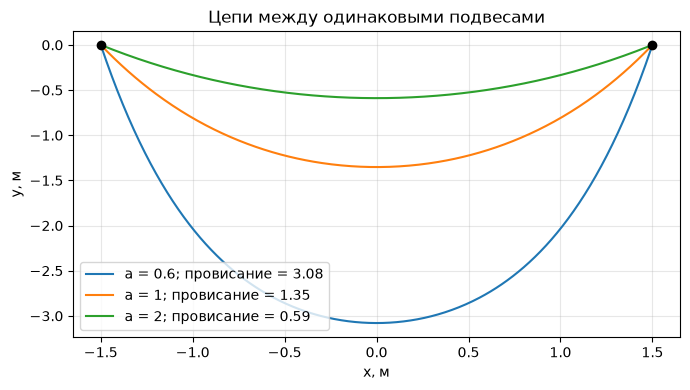

In [7]:
L = 1.5
x = np.linspace(-L, L, 400)
fig, ax = plt.subplots(figsize=(7,4))
for a_chain in [0.6, 1, 2]:
    y = a_chain*(np.cosh(x/a_chain)-np.cosh(L/a_chain))
    ax.plot(x, y, label=f'a = {a_chain}; провисание = {-y.min():.2f}')
    print('a =', a_chain, 'длина =', round(2*a_chain*np.sinh(L/a_chain),3))
ax.plot([-L,L], [0,0], 'ko')
ax.set(xlabel='x, м', ylabel='y, м', title='Цепи между одинаковыми подвесами')
ax.legend()
ax.grid(alpha=0.3)
save_plot('3_3')

In [8]:
fig, axes = plt.subplots(1,2,figsize=(8,4),dpi=100)
lines, forces, labels = [], [], []
for ax in axes:
    ax.set(xlim=(-2,2), ylim=(-5,1), xlabel='x, м', ylabel='y, м')
    ax.grid(alpha=0.3)
    ax.plot([-L,L],[0,0],'ko',ms=4)
    line, = ax.plot([], [])
    lines.append(line)
    force = ax.quiver([0,0,0],[0,0,0],[0,0,0],[0,0,0],
                      angles='xy',scale_units='xy',scale=12,color=['blue','blue','red'])
    forces.append(force)
    labels.append(ax.text(0.02,0.04,'',transform=ax.transAxes,fontsize=8))
axes[0].set_title('Меняется H, rho = 1')
axes[1].set_title('Меняется rho, H = 10')
fig.suptitle('Синие стрелки — натяжение, красная — вес участка')
fig.tight_layout(rect=[0,0,1,0.91])
def update(k):
    phase = 2*np.pi*k/119
    for j,(H,rho) in enumerate([(9+3*np.sin(phase),1),(10,0.9+0.25*np.sin(phase))]):
        a_chain = H/(rho*g)
        y = a_chain*(np.cosh(x/a_chain)-np.cosh(L/a_chain))
        lines[j].set_data(x,y)
        left,right = -0.35,0.35
        edge_y = a_chain*(np.cosh(left/a_chain)-np.cosh(L/a_chain))
        bottom_y = a_chain*(1-np.cosh(L/a_chain))
        weight = rho*g*2*a_chain*np.sinh(right/a_chain)
        forces[j].set_offsets([[left,edge_y],[right,edge_y],[0,bottom_y]])
        forces[j].set_UVC([-H,H,0],[-H*np.sinh(left/a_chain),H*np.sinh(right/a_chain),-weight])
        labels[j].set_text(f'H={H:.2f}; rho={rho:.2f}; a={a_chain:.2f}\nПровисание={-bottom_y:.2f} м')
show_animation(fig, update, '3_3_цепь')

3.4. Таутохрона

Трения нет, точку отпускают без начальной скорости. Нижняя точка имеет высоту 0. Пусть h — текущая высота, h0 — начальная. Из энергии скорость равна sqrt(2\*g\*(h0-h)). Обозначу через s(h) длину дуги от нижней точки.

Время спуска:

T(h0) = (1/sqrt(2\*g)) \* integral от 0 до h0 [s'(h)/sqrt(h0-h)] dh.

Требую T(h0) = T0. Это уравнение Абеля. Умножаю его на 1/sqrt(u-h0) и интегрирую по h0 от 0 до u. После перестановки интегралов внутренний интеграл равен pi:

integral от h до u [1/sqrt((h0-h)\*(u-h0))] dh0 = pi.

Поэтому pi\*s(u) = 2\*T0\*sqrt(2\*g\*u). Отсюда

h = pi^2\*s^2/(8\*g\*T0^2) = s^2/(8\*r), где r = g\*T0^2/pi^2.

Так как (dx/ds)^2 + (dh/ds)^2 = 1, получаю dx/ds = sqrt(1-s^2/(16\*r^2)).
Подстановка s = 4\*r\*sin(theta/2) даёт параметрические уравнения:

x = r\*(theta + sin(theta)), y = r\*(1-cos(theta)), -pi <= theta <= pi.

Это перевёрнутая циклоида, нижняя точка — (0,0). Её строит точка окружности радиуса r при качении под прямой y = 2\*r.

По касательной s'' = -g\*dh/ds = -g\*s/(4\*r).
Для старта из s0 без скорости: s(t) = s0\*cos(sqrt(g/(4\*r))\*t).
Первый приход в s = 0 происходит при T0 = pi\*sqrt(r/g). Это время не зависит от s0.

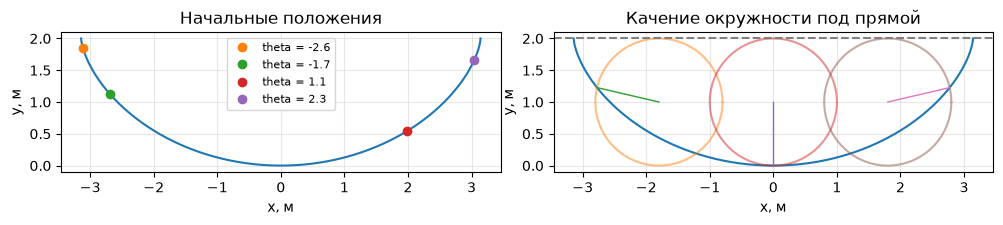

Время спуска: 1.0030333403553238
Начальная высота: 1.8569 время: 1.00303334
Начальная высота: 1.1288 время: 1.00303334
Начальная высота: 0.5464 время: 1.00303334
Начальная высота: 1.6663 время: 1.00303334


In [9]:
r = 1
angle = np.linspace(-np.pi,np.pi,600)
cx = r*(angle+np.sin(angle))
cy = r*(1-np.cos(angle))
starts = np.array([-2.6,-1.7,1.1,2.3])
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].plot(cx,cy)
for theta in starts:
    axes[0].plot(r*(theta+np.sin(theta)),r*(1-np.cos(theta)),'o',label=f'theta = {theta}')
axes[0].set_title('Начальные положения')
axes[0].legend(fontsize=8)
axes[1].plot(cx,cy,label='Циклоида')
phi = np.linspace(0,2*np.pi,120)
for theta in [-1.8,0,1.8]:
    center = r*theta
    axes[1].plot(center+r*np.cos(phi), r+r*np.sin(phi), alpha=0.5)
    axes[1].plot([center,r*(theta+np.sin(theta))],[r,r*(1-np.cos(theta))],lw=1)
axes[1].axhline(2*r,color='gray',ls='--')
axes[1].set_title('Качение окружности под прямой')
for ax in axes:
    ax.set(xlabel='x, м',ylabel='y, м')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
save_plot('3_4')
T0 = np.pi*np.sqrt(r/g)
print('Время спуска:', T0)
for theta in abs(starts):
    h0 = r*(1-np.cos(theta))
    # Подстановка h = h0*sin(u)^2 устраняет особенности на концах интеграла.
    value = quad(lambda u: 2*np.sqrt(r/g), 0, np.pi/2)[0]
    print('Начальная высота:', round(h0,4), 'время:', round(value,8))

In [10]:
fig, axes = plt.subplots(1,2,figsize=(8,3.7),dpi=100)
for ax in axes:
    ax.plot(cx,cy,color='gray')
    ax.set(xlim=(-4.5,4.5),ylim=(-0.25,2.4),xlabel='x',ylabel='y')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
axes[0].set_title('Одновременный спуск')
axes[1].set_title('Построение циклоиды')
axes[1].axhline(2*r,color='gray',ls='--')
balls = [axes[0].plot([],[],'o',ms=6)[0] for _ in starts]
text = axes[0].text(0.02,0.05,'',transform=axes[0].transAxes,fontsize=8)
circle, = axes[1].plot([],[],color='blue',lw=1)
radius, = axes[1].plot([],[],color='blue',lw=1)
point, = axes[1].plot([],[],'ro',ms=5)
trail, = axes[1].plot([],[],color='tomato',lw=2)
fig.tight_layout()
def update(k):
    t = T0*k/119
    s = 4*r*np.sin(starts/2)*np.cos(np.sqrt(g/(4*r))*t)
    theta = 2*np.arcsin(s/(4*r))
    for line,q in zip(balls,theta):
        line.set_data([r*(q+np.sin(q))],[r*(1-np.cos(q))])
    text.set_text(f't={t:.3f} с; общее время={T0:.3f} с')
    q = -np.pi+2*np.pi*k/119
    circle.set_data(r*q+r*np.cos(phi), r+r*np.sin(phi))
    px,py = r*(q+np.sin(q)),r*(1-np.cos(q))
    radius.set_data([r*q,px],[r,py]);point.set_data([px],[py])
    qline = np.linspace(-np.pi,q,200)
    trail.set_data(r*(qline+np.sin(qline)),r*(1-np.cos(qline)))
show_animation(fig,update,'3_4_таутохрона')

3.5. Математический маятник

Длина стержня l, масса точки m. Угол theta отсчитываю от вертикали вниз.
Касательная составляющая силы тяжести равна -m\*g\*sin(theta), ускорение по касательной — l\*theta''.

m\*l\*theta'' = -m\*g\*sin(theta), то есть theta'' + (g/l)\*sin(theta) = 0.

Для малых углов sin(theta) примерно равно theta:

theta(t) = theta0\*cos(omega0\*t) + v0/omega0\*sin(omega0\*t), omega0 = sqrt(g/l).
Период малых колебаний T = 2\*pi\*sqrt(l/g).

Умножение уравнения на theta' даёт закон сохранения энергии:

E = m\*l^2\*(theta')^2/2 + m\*g\*l\*(1-cos(theta)).

При старте без скорости из угла theta0 < pi:

t = sqrt(l/(2\*g)) \* integral от theta до theta0 [1/sqrt(cos(u)-cos(theta0))] du.

Замена sin(u/2) = k\*sin(phi), k = sin(theta0/2), приводит к эллиптическому интегралу.
Полный период: T = 4\*sqrt(l/g)\*K(k^2), где
K(k^2) = integral от 0 до pi/2 [1/sqrt(1-k^2\*sin(phi)^2)] dphi.

Точное решение для theta0 > 0 и v0 = 0:

theta(t) = 2\*arcsin(k\*sn(K(k^2)-sqrt(g/l)\*t, k^2)).

При theta0 -> 0 получаю обычный период, а при theta0 -> pi период растёт без ограничения.
На фазовой плоскости при E < 2\*m\*g\*l идут колебания, при E > 2\*m\*g\*l — вращения.
Граница между ними — сепаратриса E = 2\*m\*g\*l:

theta' = ±2\*sqrt(g/l)\*cos(theta/2), -pi <= theta <= pi.

В нижней точке равновесие устойчивое, в верхней — неустойчивое.

Малый угол изменение энергии: 1.5833756528138565e-10
Большой угол изменение энергии: 1.4040804074966218e-08
Вращение изменение энергии: 6.849745659565087e-08


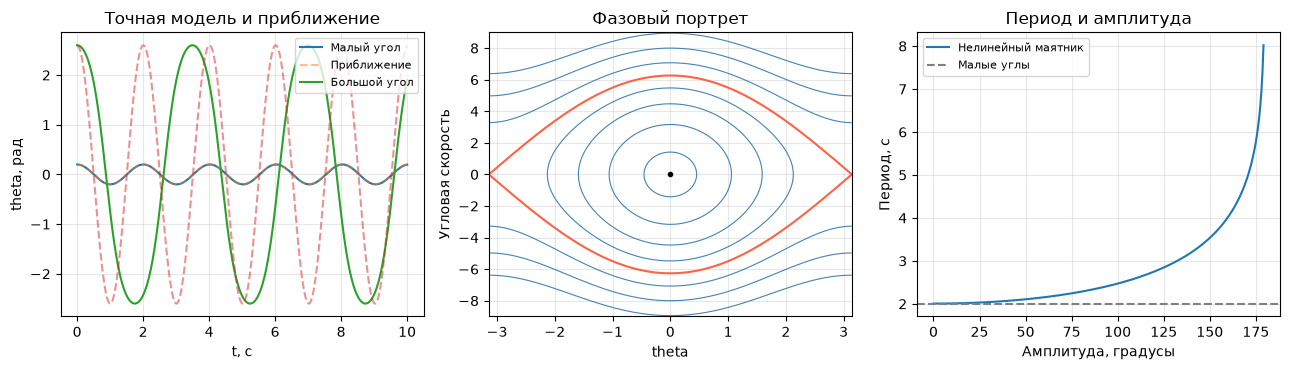

Расхождение точного и численного решения: 1.5953413416702755e-08


In [11]:
l = 1
omega0 = np.sqrt(g/l)
t = np.linspace(0,10,1000)
cases = [(0.2,0,'Малый угол'),(2.6,0,'Большой угол'),(0,8,'Вращение')]
solutions = []
for theta0,v0,name in cases:
    sol = solve_ivp(lambda t,y: [y[1],-g/l*np.sin(y[0])], [0,10], [theta0,v0],
                    t_eval=t,rtol=1e-10,atol=1e-12)
    assert sol.success
    solutions.append(sol.y)
    E = l*l*sol.y[1]**2/2+g*l*(1-np.cos(sol.y[0]))
    print(name, 'изменение энергии:', np.ptp(E))

fig, axes = plt.subplots(1,3,figsize=(13,3.8))
for (theta0,v0,name),sol in zip(cases[:2],solutions[:2]):
    axes[0].plot(t,sol[0],label=name)
    axes[0].plot(t,theta0*np.cos(omega0*t),'--',alpha=0.5, label='Приближение' if theta0 == 0.2 else None)
axes[0].set(xlabel='t, с',ylabel='theta, рад',title='Точная модель и приближение')
axes[0].legend(fontsize=8)
q,v = np.meshgrid(np.linspace(-np.pi,np.pi,300),np.linspace(-9,9,300))
E = l*l*v*v/2+g*l*(1-np.cos(q))
axes[1].contour(q,v,E,levels=[1,5,10,15,25,32,40],colors='steelblue',linewidths=0.8)
qline = np.linspace(-np.pi,np.pi,400)
for sign in [-1,1]: axes[1].plot(qline,sign*2*omega0*np.cos(qline/2),color='tomato')
axes[1].plot(0,0,'ko',ms=3)
axes[1].set(xlabel='theta',ylabel='Угловая скорость',title='Фазовый портрет')
amp = np.linspace(0,np.pi-0.015,300)
period = 4*np.sqrt(l/g)*ellipk(np.sin(amp/2)**2)
axes[2].plot(np.degrees(amp),period,label='Нелинейный маятник')
axes[2].axhline(2*np.pi/omega0,color='gray',ls='--',label='Малые углы')
axes[2].set(xlabel='Амплитуда, градусы',ylabel='Период, с',title='Период и амплитуда')
axes[2].legend(fontsize=8)
for ax in axes:ax.grid(alpha=0.3)
save_plot('3_5')
k = np.sin(2.6/2)
exact = 2*np.arcsin(k*ellipj(ellipk(k*k)-omega0*t,k*k)[0])
print('Расхождение точного и численного решения:', np.max(abs(exact-solutions[1][0])))

In [12]:
fig, axes = plt.subplots(1,2,figsize=(8,4),dpi=100)
axes[0].set(xlim=(-1.3,1.3),ylim=(-1.3,1.3),xlabel='x, м',ylabel='y, м',title='Маятник')
axes[0].set_aspect('equal')
axes[0].plot(0,0,'ko')
axes[1].set(xlim=(-np.pi,np.pi),ylim=(-9,9),xlabel='theta',ylabel='Угловая скорость',title='Фазовая плоскость')
for sign in [-1,1]: axes[1].plot(qline,sign*2*omega0*np.cos(qline/2),color='gray',lw=0.6)
rods, traces, dots = [],[],[]
for color,(_,_,name) in zip(['blue','tomato','green'],cases):
    rods.append(axes[0].plot([],[],'o-',color=color,ms=5,label=name)[0])
    traces.append(axes[1].plot([],[],color=color,lw=0.7)[0])
    dots.append(axes[1].plot([],[],'o',color=color,ms=4)[0])
axes[0].legend(fontsize=7,loc='upper left')
for ax in axes:ax.grid(alpha=0.3)
label = fig.suptitle('')
fig.tight_layout(rect=[0,0,1,0.94])
indices = np.linspace(0,len(t)-1,150).astype(int)
def update(frame):
    k = indices[frame]
    label.set_text(f't = {t[k]:.2f} с')
    for rod,trace,dot,sol in zip(rods,traces,dots,solutions):
        theta,velocity = sol[:,k]
        rod.set_data([0,l*np.sin(theta)],[0,-l*np.cos(theta)])
        angle = (sol[0,:k+1]+np.pi) % (2*np.pi)-np.pi
        angle = angle.copy()
        jump = np.r_[False,abs(np.diff(angle)) > np.pi]
        angle[jump] = np.nan
        trace.set_data(angle,sol[1,:k+1])
        dot.set_data([(theta+np.pi)%(2*np.pi)-np.pi],[velocity])
show_animation(fig,update,'3_5_маятник',frames=150)

Материал по уравнению Абеля: [Abel Integral Equations](https://appliedmath.brown.edu/sites/default/files/fractional/19%20Abel%20Integral%20Equations.pdf).